# Sprint 2 — GenAI · Análise Exploratória de Dados
### Manutenção preditiva de motores elétricos (Challenge Forzy / FIAP)

**Entregável 1 — Descrição do problema preditivo.** A tarefa é uma **classificação
multiclasse** do estado operacional do motor a partir de leituras de sensores:
`falha ∈ {0 Normal, 1 Desbalanceamento, 2 Superaquecimento, 3 Falha mecânica}`.
Antecipar a classe de falha é o que viabiliza a manutenção *preditiva* — agir antes da
parada, priorizando as três classes de falha (minoritárias), onde está o valor.

**Entregável 2 — Base de dados.** `data/motor.db` (SQLite): tabelas `motores` (20),
`leituras` (30.000 — séries de sensores 1/min) e `tipos_falha` (dicionário). Origem:
dados sintéticos com seed fixa (ver `data/BANCO.pdf`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from data_utils import load_leituras, load_tabela, FEATURES, TARGET, TIPOS_FALHA
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"] = (9, 4.5)
FIG = "../figuras"; os.makedirs(FIG, exist_ok=True)

In [2]:
df = load_leituras()
print("leituras:", df.shape, "| motores:", df.motor_id.nunique())
print("período:", df.timestamp.min(), "->", df.timestamp.max())
display(df.head())
display(load_tabela("tipos_falha"))

leituras: (30000, 11) | motores: 20
período: 2026-01-01 00:00:00 -> 2026-01-02 00:59:00


,motor_id,timestamp,rotacao_rpm,vibracao_mm_s,temperatura_c,corrente_a,falha,fabricante,modelo,potencia_kw,ano_instalacao
0,1,2026-01-01 00:00:00,1767.32,2.574,72.22,12.37,0,Siemens,1LE0,22.0,2022
1,1,2026-01-01 00:01:00,1783.54,2.858,71.72,13.75,0,Siemens,1LE0,22.0,2022
2,1,2026-01-01 00:02:00,1819.29,1.815,67.94,13.24,0,Siemens,1LE0,22.0,2022
3,1,2026-01-01 00:03:00,1808.19,2.641,75.53,12.18,0,Siemens,1LE0,22.0,2022
4,1,2026-01-01 00:04:00,1815.67,3.457,72.20,12.24,0,Siemens,1LE0,22.0,2022


,codigo,nome,descricao
0,0,Normal,Operacao dentro dos parametros esperados.
1,1,Desbalanceamento,Vibracao alta e rotacao instavel.
2,2,Superaquecimento,Temperatura e corrente elevadas.
3,3,Falha mecanica,Queda de rotacao com vibracao e corrente altas.


## 1. Distribuição da variável-alvo

,classe,n,%
0,Normal,26291,87.64
1,Desbalanceamento,1205,4.02
2,Superaquecimento,1718,5.73
3,Falha mecânica,786,2.62


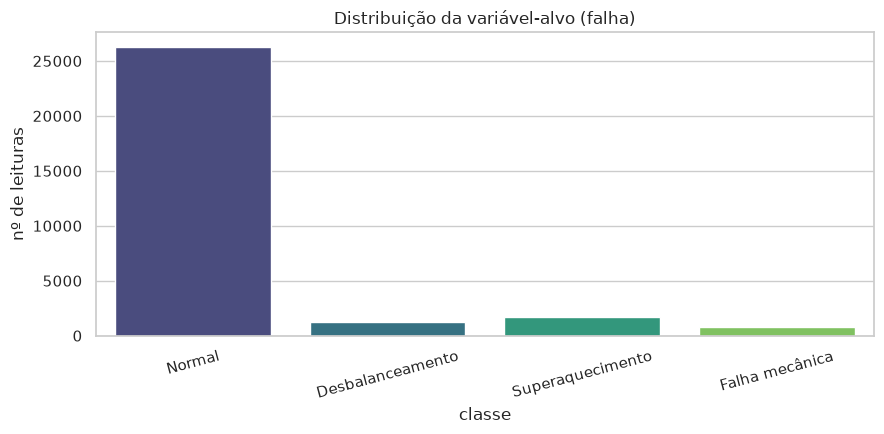

In [3]:
vc = df[TARGET].value_counts().sort_index()
dist = pd.DataFrame({"classe": [TIPOS_FALHA[c] for c in vc.index],
                     "n": vc.values, "%": (100*vc.values/len(df)).round(2)})
display(dist)
ax = sns.barplot(data=dist, x="classe", y="n", hue="classe", legend=False, palette="viridis")
ax.set_title("Distribuição da variável-alvo (falha)"); ax.set_ylabel("nº de leituras")
plt.xticks(rotation=15); plt.tight_layout(); plt.savefig(f"{FIG}/01_distribuicao_alvo.png", dpi=110); plt.show()

**Interpretação.** Forte desbalanceamento: ~87,6% das leituras são *Normal* e só ~12,4%
são falhas, repartidas em três tipos (a *falha mecânica* é a mais rara). Isso exige
`class_weight` no modelo e métricas **por classe** (recall/F1) — acurácia global
sozinha enganaria, pois prever "tudo normal" já daria ~88%.

## 2. Distribuição dos sensores por classe de falha

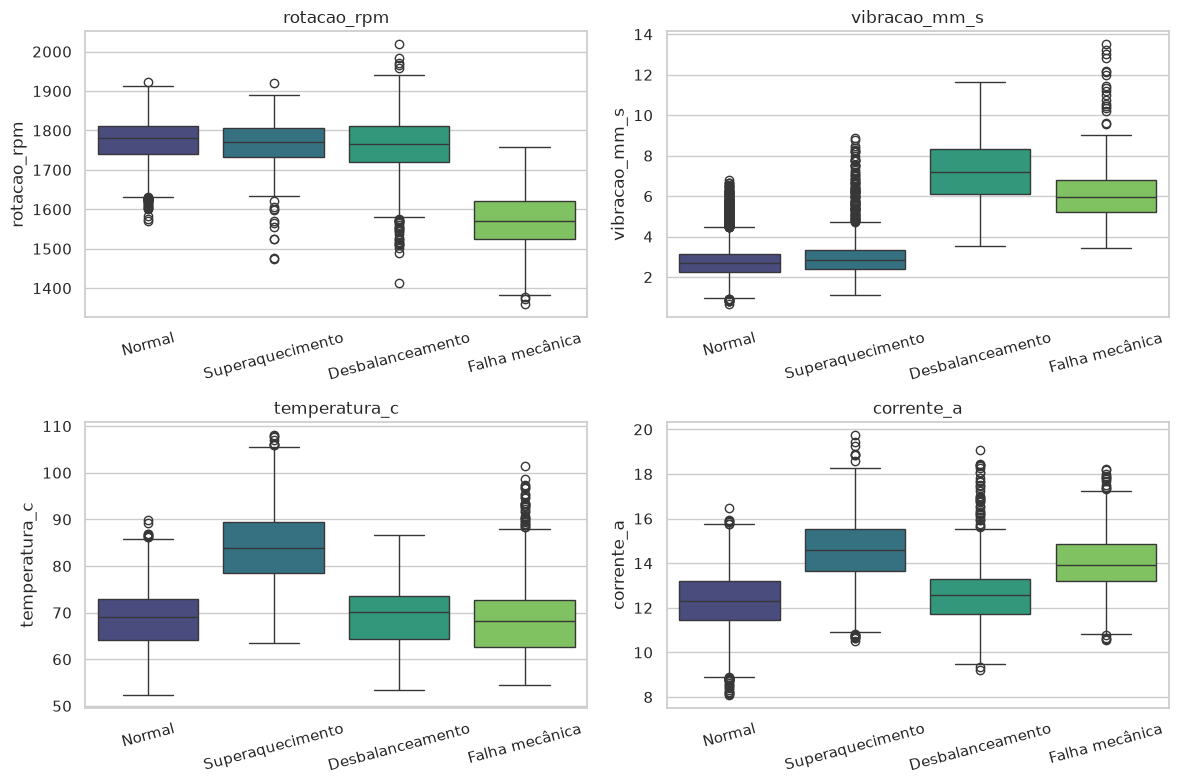

,rotacao_rpm,vibracao_mm_s,temperatura_c,corrente_a
falha,,,,
Desbalanceamento,1762.44,7.29,69.12,12.62
Falha mecânica,1570.53,6.10,68.72,14.05
Normal,1776.08,2.73,68.50,12.32
Superaquecimento,1768.16,3.03,84.30,14.59


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.ravel(), FEATURES):
    d = df.assign(classe=df[TARGET].map(TIPOS_FALHA))
    sns.boxplot(data=d, x="classe", y=feat, hue="classe", legend=False, ax=ax, palette="viridis")
    ax.set_title(feat); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.savefig(f"{FIG}/02_sensores_por_classe.png", dpi=110); plt.show()
df.groupby(df[TARGET].map(TIPOS_FALHA))[FEATURES].mean().round(2)

**Interpretação (ligação com o comportamento físico).**
- **Desbalanceamento** → `vibracao_mm_s` claramente elevada (vibração é a assinatura).
- **Superaquecimento** → `temperatura_c` e `corrente_a` acima do normal simultaneamente.
- **Falha mecânica** → `rotacao_rpm` cai e vibração/corrente sobem — combina sintomas
  das outras duas, o que antecipa a confusão que veremos no modelo.

## 3. Outliers e amplitude das leituras

,rotacao_rpm,vibracao_mm_s,temperatura_c,corrente_a
count,30000.00,30000.00,30000.00,30000.00
mean,1769.70,3.02,69.43,12.51
std,59.31,1.29,6.85,1.35
min,1358.73,0.65,52.28,8.08
25%,1735.35,2.30,64.46,11.56
50%,1777.40,2.75,69.52,12.45
75%,1811.01,3.29,73.49,13.39
max,2018.43,13.50,108.06,19.74


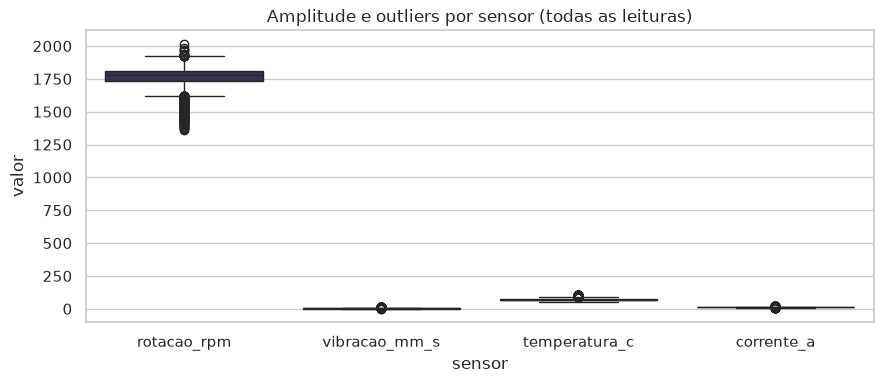

In [5]:
display(df[FEATURES].describe().round(2))
fig, ax = plt.subplots(figsize=(9,4))
sns.boxplot(data=df[FEATURES].melt(var_name="sensor", value_name="valor"),
            x="sensor", y="valor", hue="sensor", legend=False, palette="mako", ax=ax)
ax.set_title("Amplitude e outliers por sensor (todas as leituras)")
plt.tight_layout(); plt.savefig(f"{FIG}/03_outliers.png", dpi=110); plt.show()

**Interpretação.** Os "outliers" superiores em vibração, temperatura e corrente **não
são ruído a remover** — são justamente as janelas de falha. Tratá-los como erro
apagaria o sinal de interesse; mantemos as leituras e deixamos o rótulo `falha` separar.

## 4. Evolução temporal — a rampa progressiva de deterioração

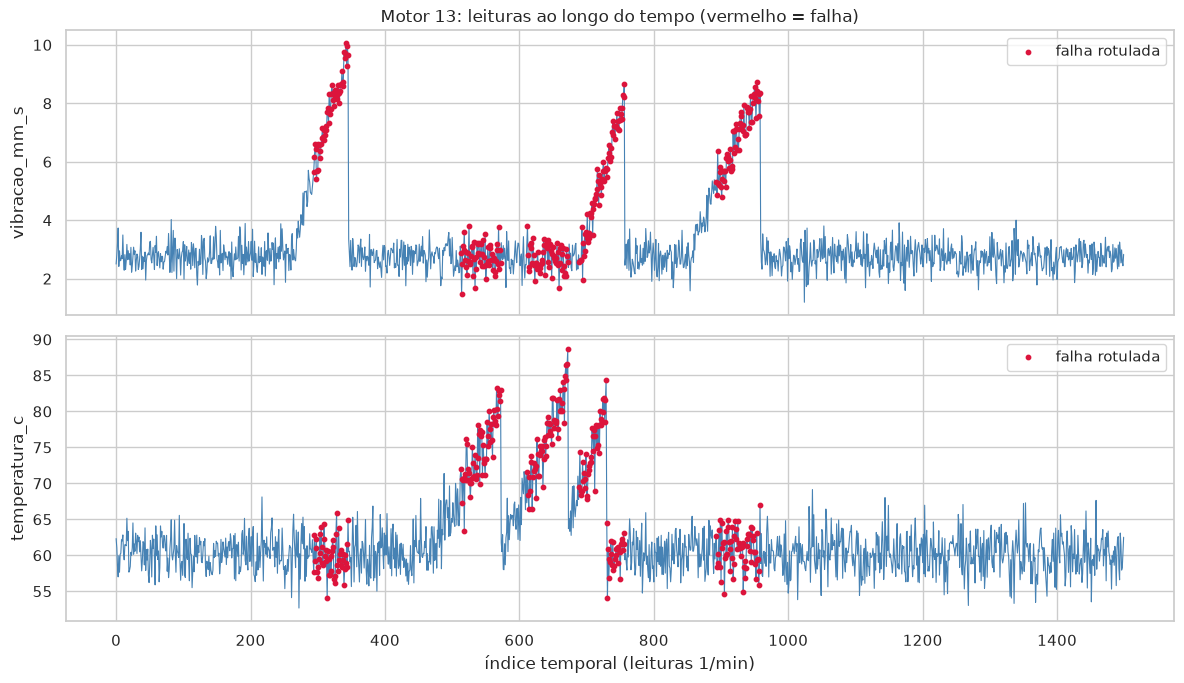

In [6]:
# Escolhe um motor que tenha falhas e plota a série de um sensor, marcando as falhas.
alvo = (df[df[TARGET] > 0].motor_id.value_counts().idxmax())
m = df[df.motor_id == alvo].reset_index(drop=True)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, feat in zip(axes, ["vibracao_mm_s", "temperatura_c"]):
    ax.plot(m.index, m[feat], lw=0.8, color="steelblue")
    falha_pts = m[m[TARGET] > 0]
    ax.scatter(falha_pts.index, falha_pts[feat], s=10, color="crimson", label="falha rotulada", zorder=3)
    ax.set_ylabel(feat); ax.legend(loc="upper right")
axes[0].set_title(f"Motor {alvo}: leituras ao longo do tempo (vermelho = falha)")
axes[1].set_xlabel("índice temporal (leituras 1/min)")
plt.tight_layout(); plt.savefig(f"{FIG}/04_evolucao_temporal.png", dpi=110); plt.show()

**Interpretação.** As falhas ocorrem em **janelas** com subida gradual (rampa). Como o
BANCO.md diz, o rótulo só acende acima de ~40% da intensidade — então as leituras
*imediatamente antes* do ponto vermelho já carregam o padrão emergindo. Isso é a
justificativa empírica para, numa próxima sprint, usar **features de janela móvel**
(médias/variações móveis) e antecipar ainda mais a detecção.

## 5. Correlação entre sensores

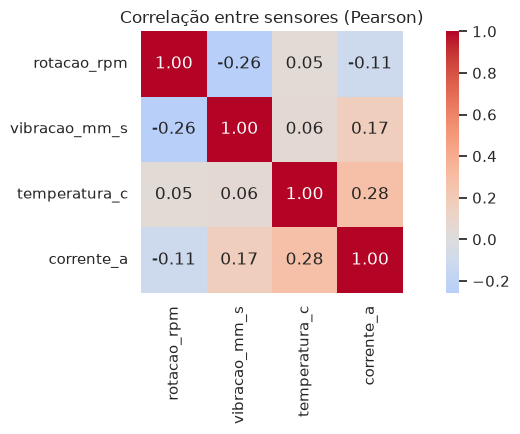

In [7]:
corr = df[FEATURES].corr()
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
ax.set_title("Correlação entre sensores (Pearson)")
plt.tight_layout(); plt.savefig(f"{FIG}/05_correlacao.png", dpi=110); plt.show()

**Interpretação.** A correlação global entre sensores é fraca em regime normal (cada um
mede um fenômeno diferente), mas temperatura×corrente tende a andar junto nos eventos de
superaquecimento. A baixa colinearidade geral é boa: cada sensor agrega informação
própria ao modelo.

## Conclusões da EDA
1. Problema multiclasse fortemente **desbalanceado** → usar `class_weight` + métricas por classe.
2. Cada falha tem **assinatura física** coerente nos sensores → as 4 leituras carregam sinal.
3. As falhas são **janelas com rampa** → janela móvel é a evolução natural (próxima sprint).
4. Outliers altos = falhas reais → **não** remover.

Segue para o notebook `treinamento.ipynb`.